# 3D visualisation in PyGMT

[Lavayssière et al. 2019](https://www.sciencedirect.com/science/article/abs/pii/S0377027319301684?via%3Dihub#f0020) use a range of figures to show seismicity from Corbetti volcano, Ethiopia. We can replicate some of those here, using 3D plotting and topography data available from PyGMT. 

### Imports

In [1]:
import pygmt
import pandas as pd
import matplotlib.dates as mdates
import numpy as np

### Plotting in 3D

We can set our basic parameters up the top of the script, so they are in one place should we need to change them. We'll used a smaller frame for our regional map. Just like we set a min/max for longiude and latitude, we can also set a min/max for elevation. By default, topography downloaded via PyGMT is in metres. 

We can set the perspective that we look at the 3D space, with azimuth (0 - 360 degrees) and an angle of declination from 0 degrees horizontal, to 90 degrees immediately looking down on the surface. 

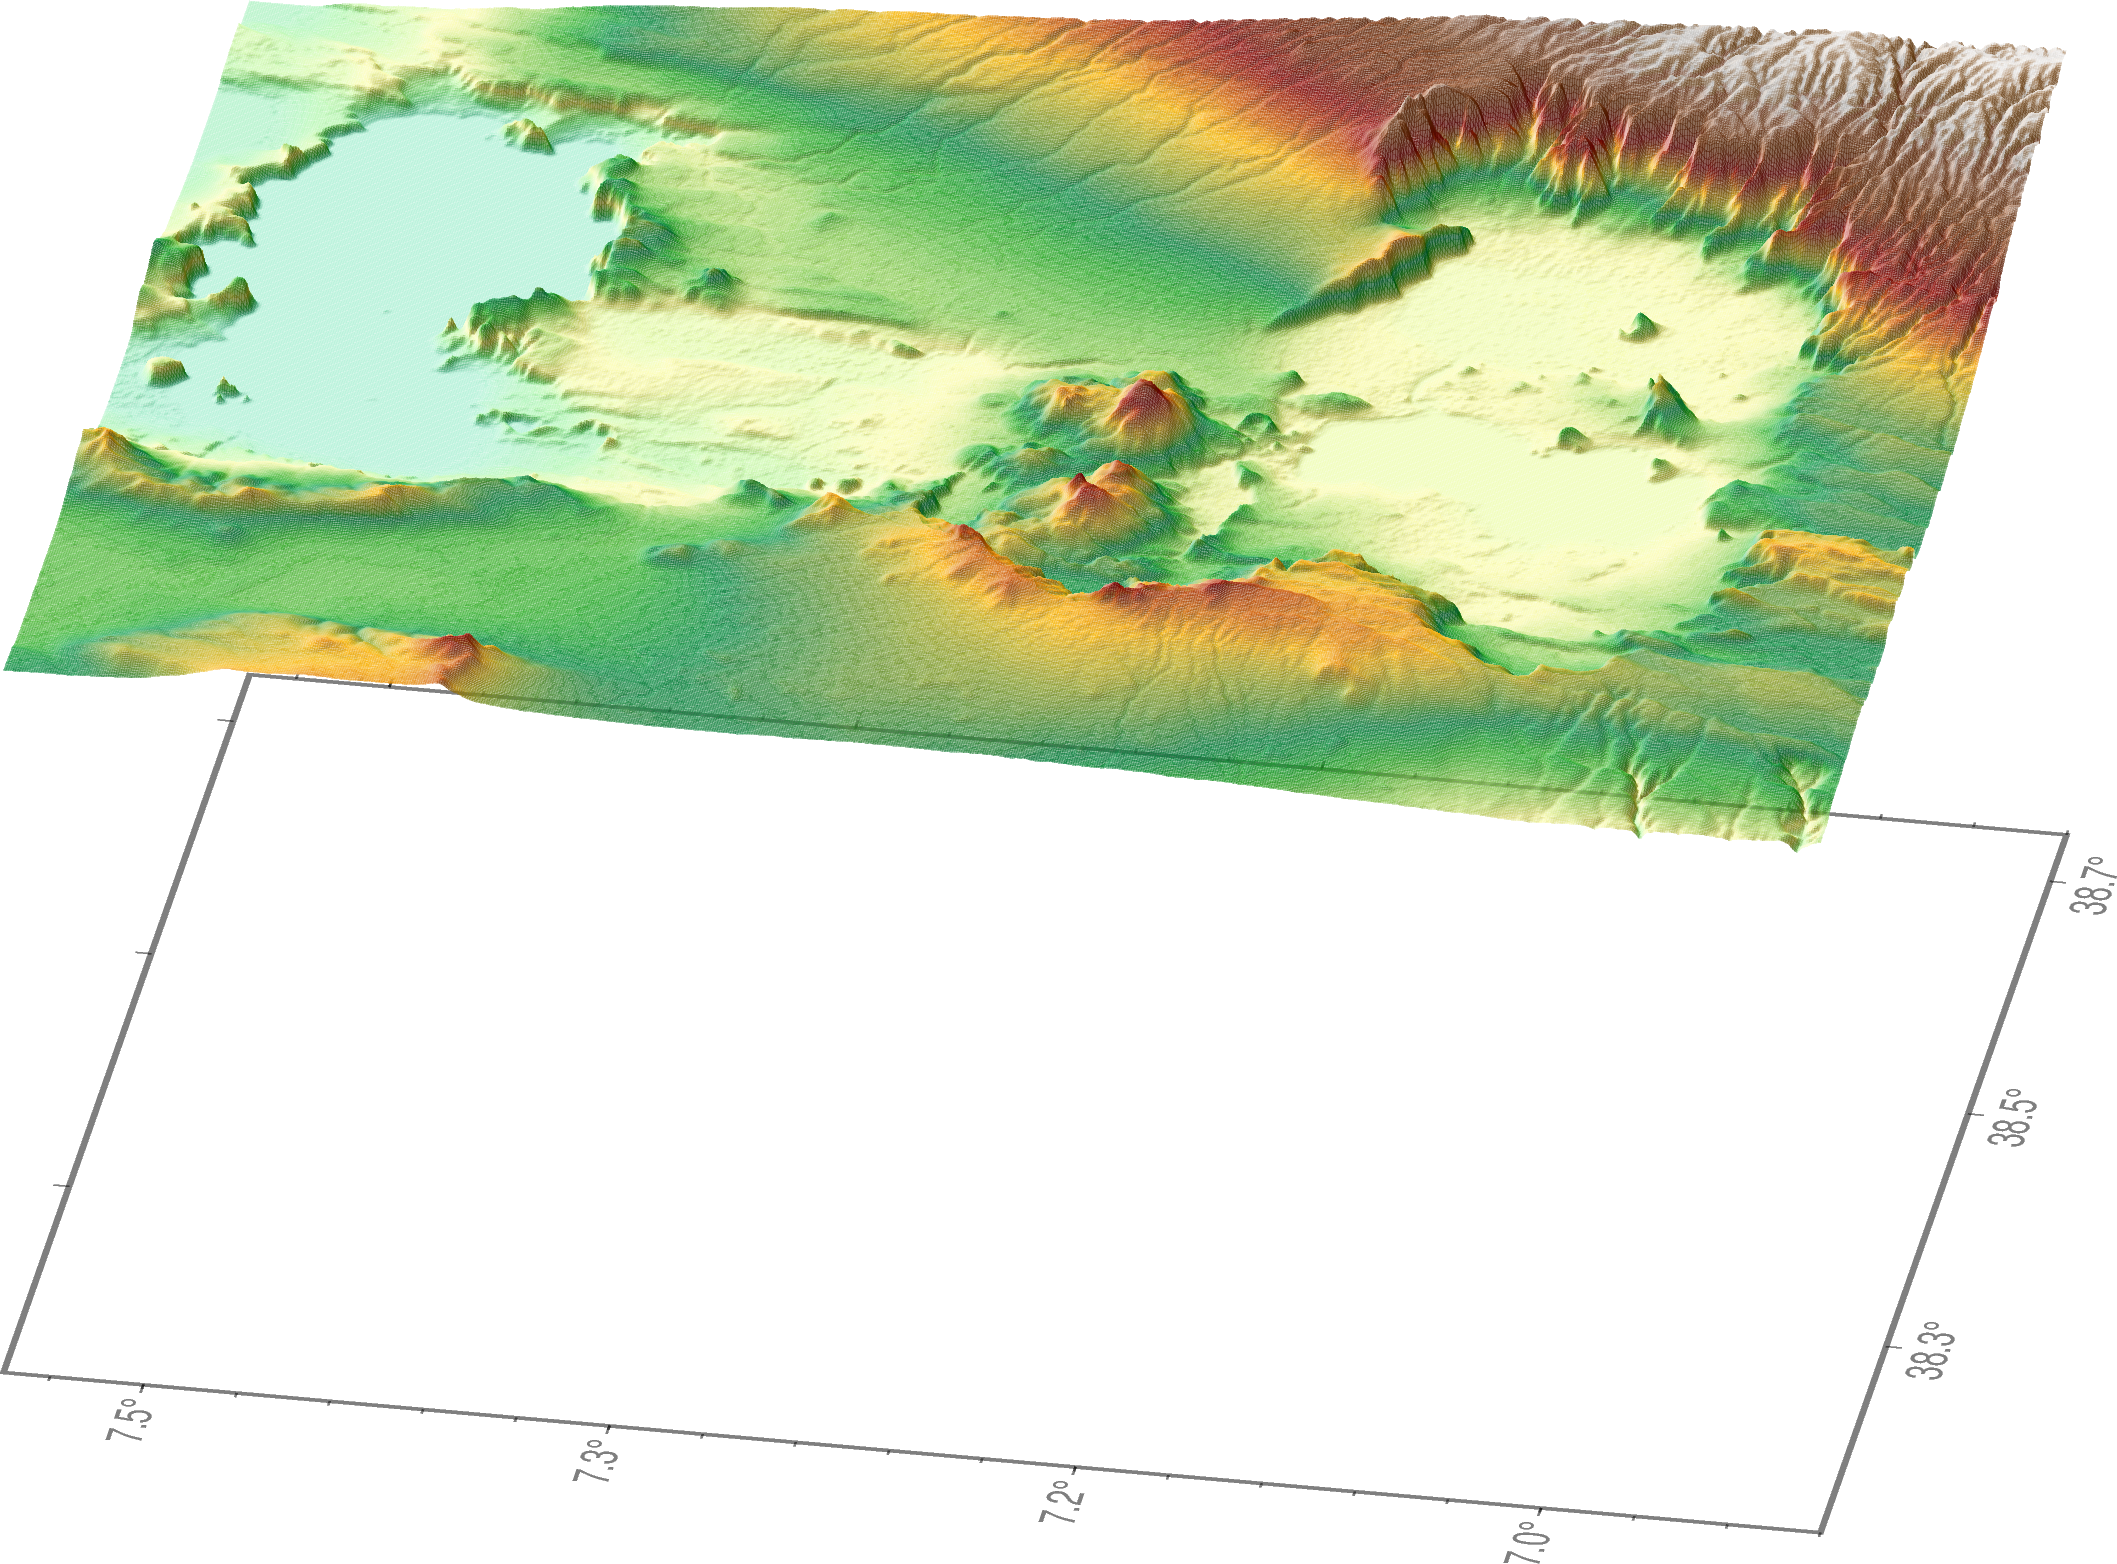

In [2]:

# Corbetti only now, zoom in
latmin = 6.9
latmax = 7.55
lonmin = 38.2
lonmax = 38.7
elevmin = -5000
elevmax = 5000
proj = "M12c"
frame = ["xa", "yaf", "za1000f500", "WSne"]
perspective=[260,30]
fig = pygmt.Figure()

pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_TITLE='12p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")

grid = pygmt.datasets.load_earth_relief(resolution ="03s", region=[lonmin,lonmax,latmin,latmax])
cmap2 = pygmt.makecpt(cmap="earth", series=[float(grid.min()), float(grid.max()), 10])
cutgrd = pygmt.grdcut(grid=grid, region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax])

fig.grdview(
    grid=cutgrd,
    perspective=perspective,
    frame=frame,
    projection=proj,
    zscale="0.001c",
    # Set the surftype to "surface"
    surftype="s",
    shading="+a45",
    cmap="earth",
    region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax],
    transparency=50
)

fig.show()

### Corbetti seismic data

If we look at the seismic locations, we can work out what the deepest event is to find our minimum elevation (negative). We can also extract the highest elevation within the topography grid. 

In [3]:
eq_data = pd.read_csv('./Data/Corbetti/Corbetti_catalog.txt', sep='\t')
eq_data

,YearMonthDay,HrMinSec,Latitude,Latitude Error,Longitude,Longitude Error,Depth,Depth Error,Magnitude
0,20160216,11:40:58,7.05953,0.917074,38.4567,0.628847,7.00195,0.589946,3.013927
1,20160217,01:38:48,7.09950,0.757719,38.4849,1.021870,7.47070,1.472740,1.880876
2,20160220,02:54:06,7.06531,1.180680,38.4687,0.917897,9.49219,0.958281,2.757428
3,20160224,01:58:04,7.26169,0.718432,38.3907,0.423283,7.99805,0.227225,2.181481
4,20160224,22:49:52,7.08528,1.958420,38.4954,1.148930,2.87109,1.979490,2.278022
...,...,...,...,...,...,...,...,...,...
117,20170912,21:46:11,7.19432,0.289216,38.3935,0.504107,3.42773,0.503287,1.211208
118,20170919,01:32:43,7.18006,0.246806,38.4448,0.145049,5.68359,0.319427,1.221953
119,20170919,01:34:11,7.19637,0.750207,38.4484,0.611955,6.70898,1.731730,1.966282
120,20170919,01:41:09,7.18268,1.341640,38.4596,0.625779,3.48633,0.891875,1.286699


In [4]:
print((eq_data.Depth*-1000).min()) # Data in file is in km
print(cutgrd.max())

-22119.1
<xarray.DataArray 'z' ()>
array(2692., dtype=float32)


Now plot the seismic data but without any topography. Play around with the azimuth and incidence angle to see which combination best shows the features of the data. One unfortunate quirk with PyGMT plot3d is that, if you wish to scale the size of points by a third variable, this can only be done with cubes. Ghostscript cannot support the visuals of scaling spheres. 

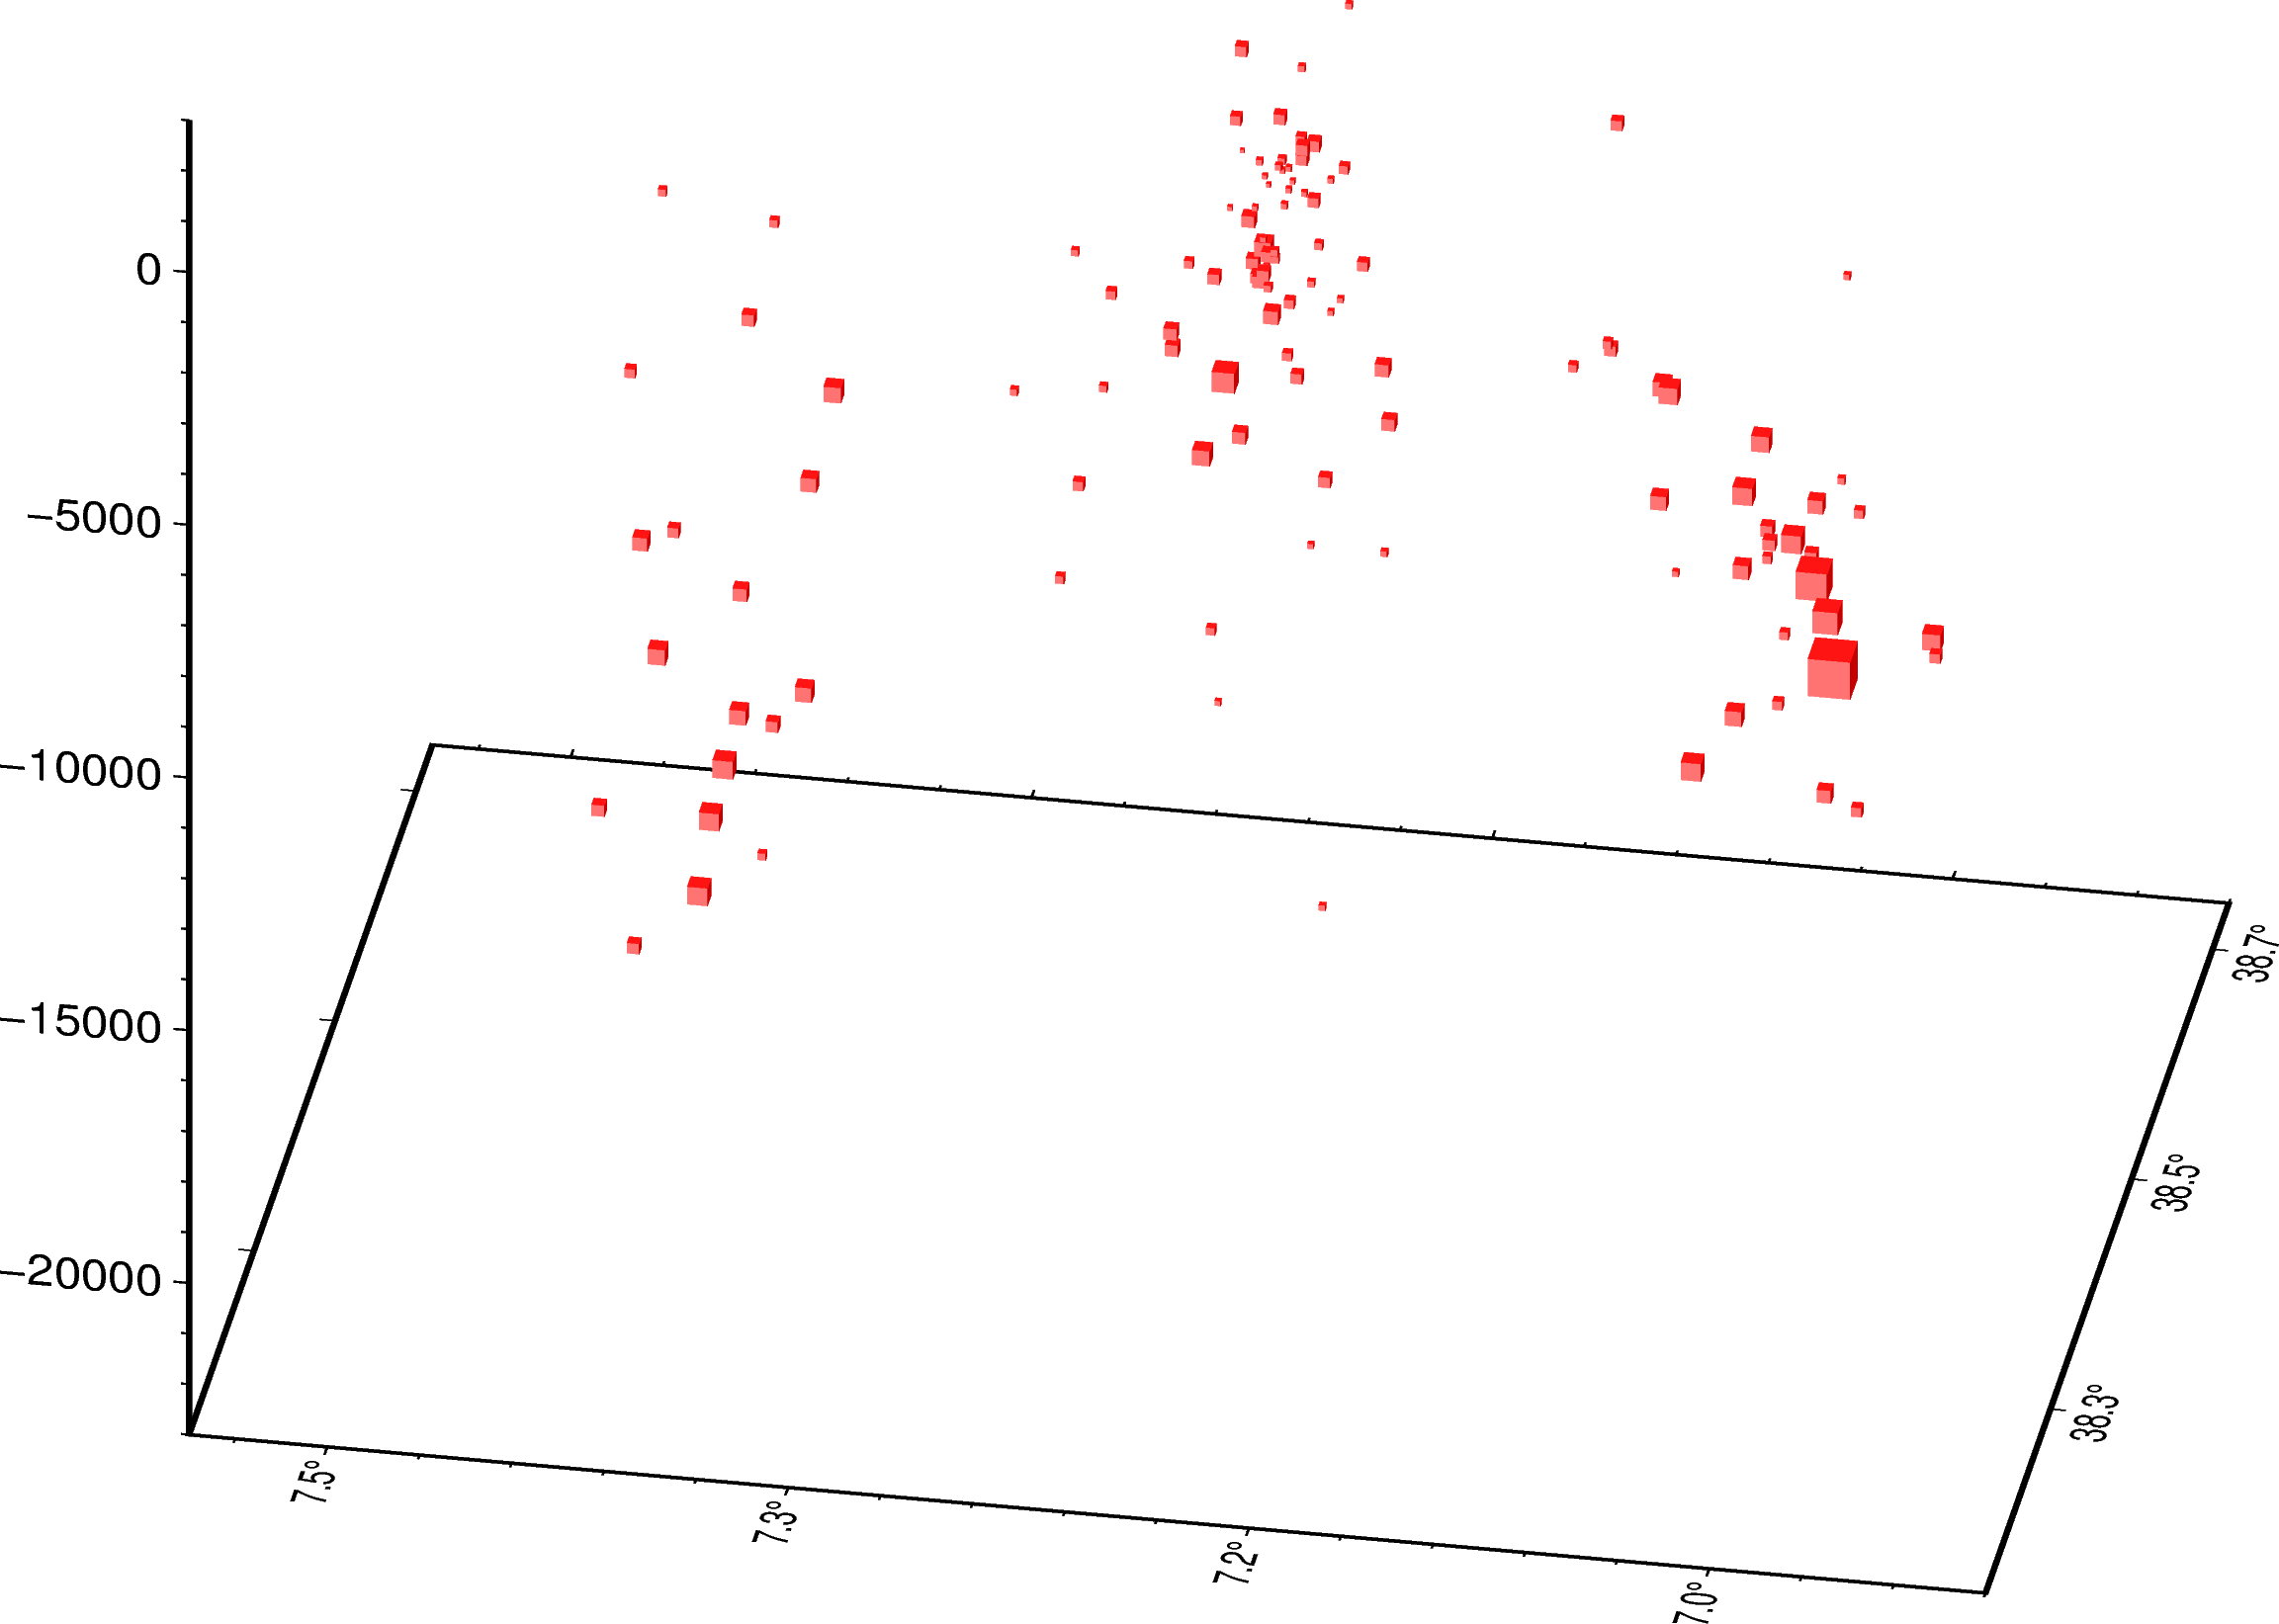

In [5]:
elevmin = -23000
elevmax = 3000
frame = ["xa", "yaf", "za5000f1000", "WSneZ"]
perspective = [260,30]

fig = pygmt.Figure()

pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_TITLE='12p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")


# Plot hypocenters
fig.plot3d(x=eq_data.Longitude,
           y=eq_data.Latitude,
           z=eq_data.Depth*-1000,
           style="uc",
           size=0.02*(2**eq_data.Magnitude),
           fill="red",
           zscale="0.0005c",
           perspective=perspective,
           projection=proj,
           frame=frame,
           region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax]
           )

fig.show()


We need to make a bit of a hack to plot the points coloured by time. We can merge the strings to make a datetime column.

In [6]:
# Merge 'YearMonthDay' and 'HrMinSec' columns into a single string column, add space between
eq_data['datetime_str'] = eq_data['YearMonthDay'].astype(str) + ' ' + eq_data['HrMinSec'].astype(str)

# Convert the merged 'datetime_str' column to a pandas datetime object
eq_data['datetime'] = pd.to_datetime(eq_data['datetime_str'], format='%Y%m%d %H:%M:%S')

# Convert the datetime column to a float using mdates
eq_data['datetime_numeric'] =  mdates.date2num(eq_data['datetime'])

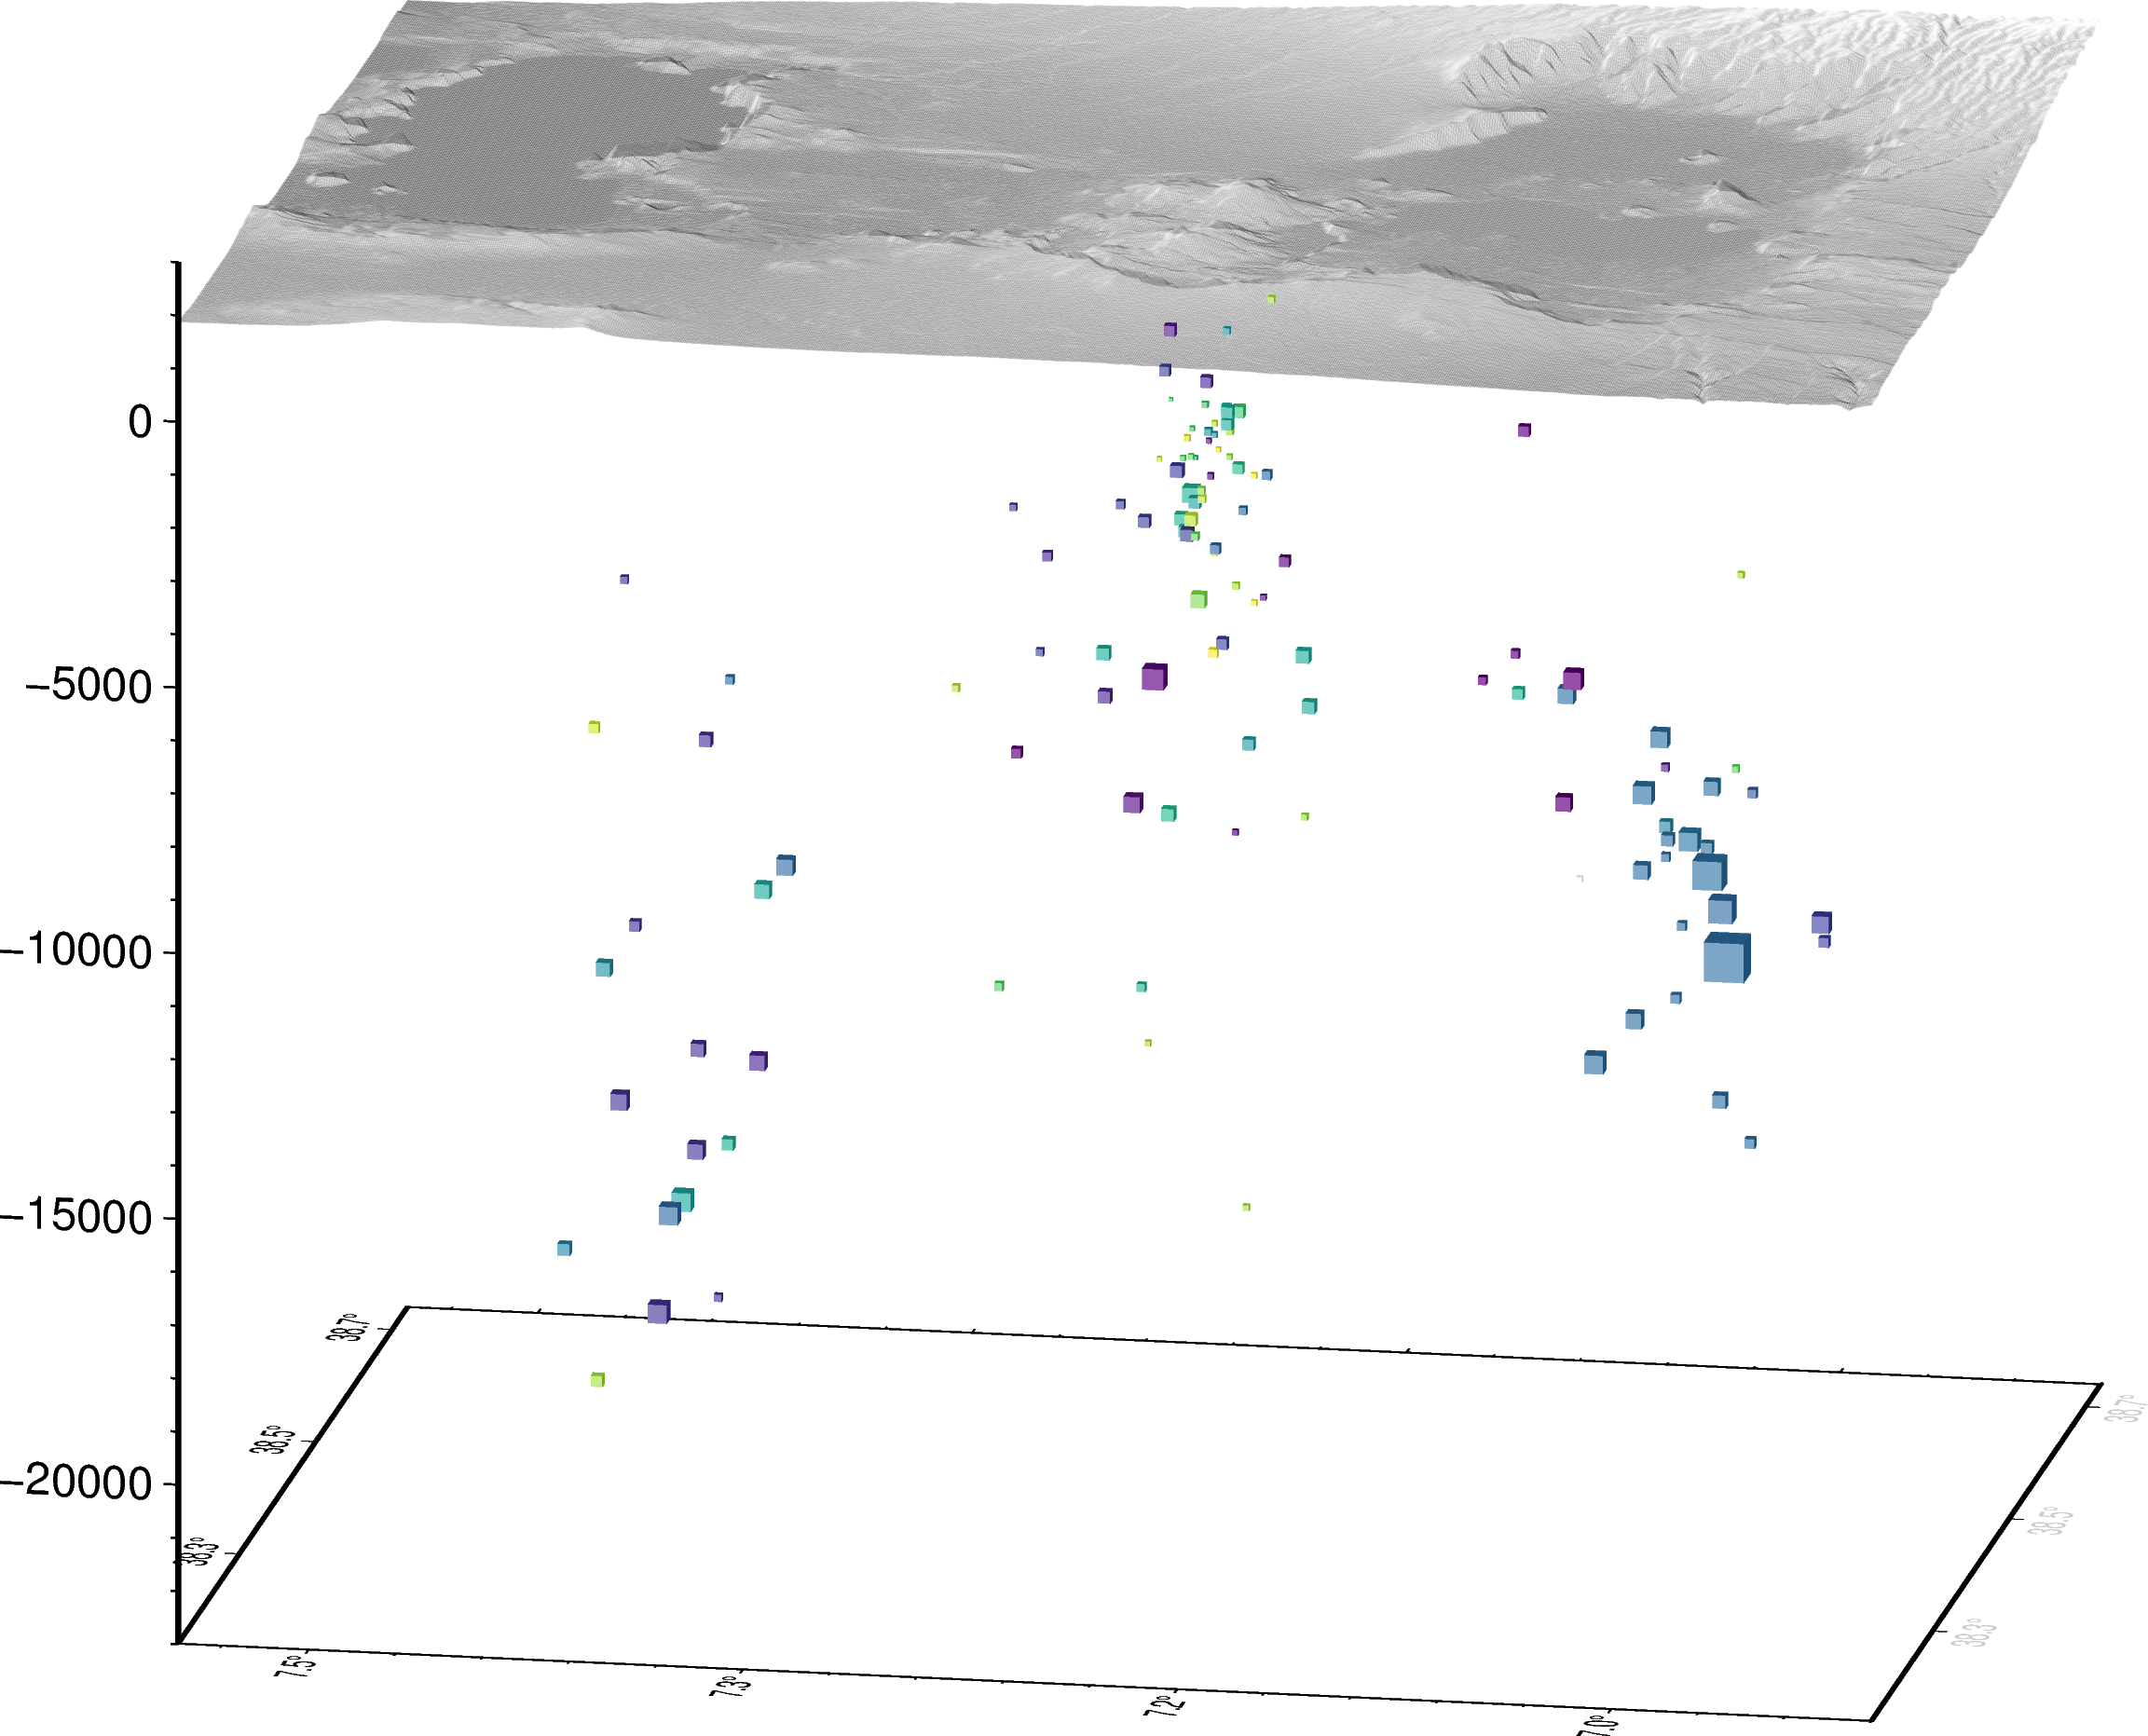

In [7]:
perspective=[260,15]

fig = pygmt.Figure()

pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_TITLE='12p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")

grid = pygmt.datasets.load_earth_relief(resolution ="03s", region=[lonmin,lonmax,latmin,latmax])
cmap2 = pygmt.makecpt(cmap="gray", series=[float(grid.min()), float(grid.max()), 10])
cutgrd = pygmt.grdcut(grid=grid, region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax])

fig.grdview(
    grid=cutgrd,
    perspective=perspective,
    frame=["xa", "yaf", "za1000f500", "WSne"],
    projection=proj,
    zscale="0.0005c",
    # Set the surftype to "surface"
    surftype="s",
    shading="+a45",
    # Set the CPT to "geo"
    cmap="gray",
    region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax],
    transparency=80
)

cmap1 = pygmt.makecpt(cmap="viridis", series=[eq_data['datetime_numeric'].min(), eq_data['datetime_numeric'].max(), "1d"])


# Plot hypocenters
fig.plot3d(x=eq_data.Longitude,
           y=eq_data.Latitude,
           z=eq_data.Depth*-1000,
           style="uc",
           size=0.02*(2**eq_data.Magnitude),
           fill=eq_data['datetime_numeric'],
           cmap=True,
           zscale="0.0005c",
           perspective=perspective,
           projection=proj,
           frame=["xa", "yaf", "za5000f1000", "WsNeZ"],
           region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax]
           )

fig.show()


We can also import the station latitudes and longitudes to plot on the surface 

In [8]:
station_data = pd.read_csv('./Data/Corbetti/station_locs.csv')
station_data

,Station Code,Latitude,Longitude
0,AJEE,7.25954,38.302601
1,BETI,7.19412,38.411720
2,BRRR,7.19894,38.476089
3,CHEF,7.14898,38.432110
4,CORB,7.22324,38.385040
5,DORE,7.03129,38.361500
6,FINH,6.96660,38.462070
7,GRIM,7.16118,38.394749
8,KADO,7.29486,38.654770
9,MILA,7.12967,38.434429


The stations do not have elevations, so we can use a PyGMT function `grdcut` to extract the elevation at a given lat/lon. This will mean our points plot on the surface. 

In [9]:
station_data_latlon = station_data[['Longitude', 'Latitude']]
track = pygmt.grdtrack(points=station_data_latlon, grid=cutgrd, newcolname="elevation")
track['Name'] = station_data['Station Code']
track

,Longitude,Latitude,elevation,Name
0,38.302601,7.25954,1942.217875,AJEE
1,38.411720,7.19412,1819.633838,BETI
2,38.476089,7.19894,1781.263616,BRRR
3,38.432110,7.14898,1723.504931,CHEF
4,38.385040,7.22324,1823.708955,CORB
5,38.361500,7.03129,1711.978132,DORE
6,38.462070,6.96660,1788.527176,FINH
7,38.394749,7.16118,1740.033360,GRIM
8,38.654770,7.29486,1945.004985,KADO
9,38.434429,7.12967,1698.085572,MILA


We can not plot the station data on the surface of the topography, at the correct height, and show the earthquake locations with depth.

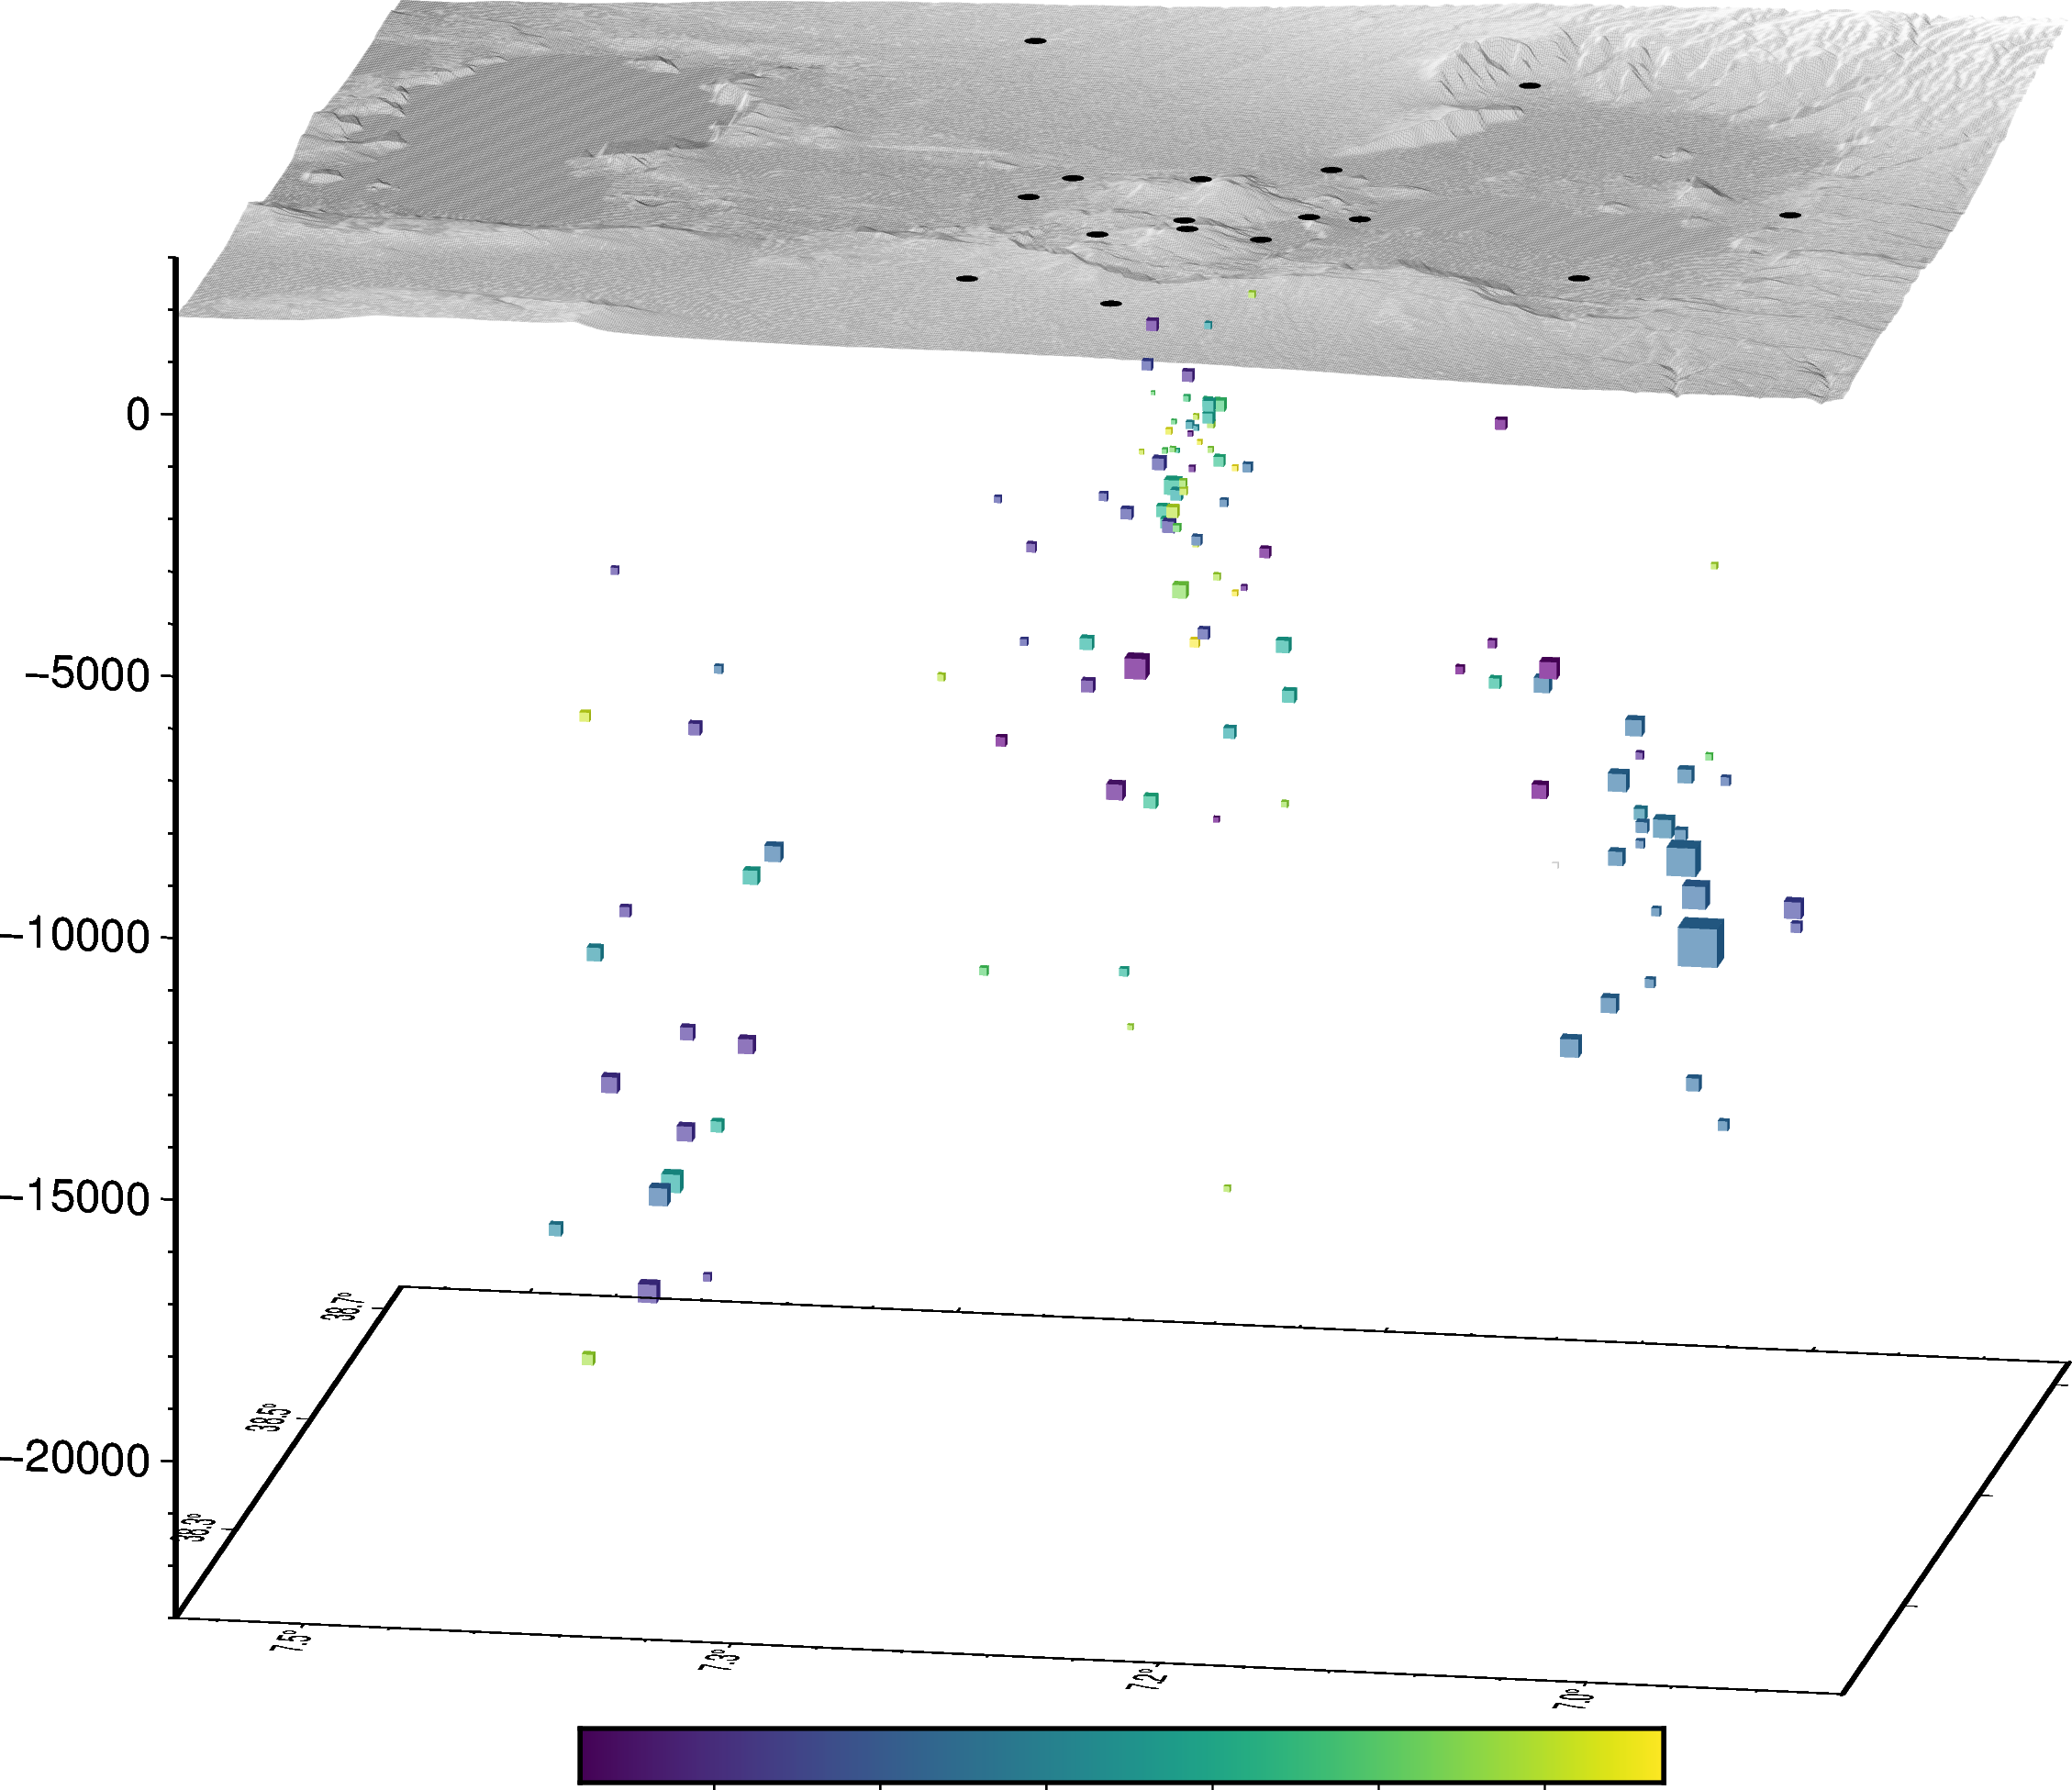

In [10]:

fig = pygmt.Figure()

pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_TITLE='12p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")

grid = pygmt.datasets.load_earth_relief(resolution ="03s", region=[lonmin,lonmax,latmin,latmax])
cmap2 = pygmt.makecpt(cmap="gray", series=[float(grid.min()), float(grid.max()), 10])
cutgrd = pygmt.grdcut(grid=grid, region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax])

fig.grdview(
    grid=cutgrd,
    perspective=perspective,
    frame=["xa", "yaf", "za5000f1000", "WsNeZ"],
    projection=proj,
    zscale="0.0005c",
    # Set the surftype to "surface"
    surftype="s",
    shading="+a45",
    # Set the CPT to "geo"
    cmap="gray",
    region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax],
    transparency=80
)

cmap1 = pygmt.makecpt(cmap="viridis", series=[eq_data['datetime_numeric'].min(), eq_data['datetime_numeric'].max(), "1d"])


# Plot hypocenters
fig.plot3d(x=eq_data.Longitude,
           y=eq_data.Latitude,
           z=eq_data.Depth*-1000,
           style="uc",
           size=0.02*(2**eq_data.Magnitude),
           fill=eq_data['datetime_numeric'],
           cmap=True,
           zscale="0.0005c",
           perspective=perspective,
           projection=proj,
           frame=["xa", "yaf", "za5000f1000", "WsNeZ"],
           region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax]
           )

fig.colorbar(frame="a100000f90",position="JBC+w10c/0.5c+h", scale=1)   

# Plot seismic stations
fig.plot3d(x=track.Longitude,
           y=track.Latitude,
           z=track.elevation,
           style="c0.2c",
           fill='black',
           zscale="0.0005c",
           perspective=perspective,
           projection=proj,
           frame=["xa", "yaf", "za5000f1000", "WsNeZ"],
           region=[lonmin,lonmax,latmin,latmax,elevmin,elevmax]
           )


fig.show()